In [3]:
import pandas as pd

# Load the dataset
file_path = r"D:\DS ASSIGNMENTS\blogs.csv"
data = pd.read_csv(file_path)
data




,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism
...,...,...
1995,Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:...,talk.religion.misc
1996,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc
1997,Xref: cantaloupe.srv.cs.cmu.edu talk.origins:4...,talk.religion.misc
1998,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc


In [4]:
# Display the first few rows and structure of the dataset
data.info(), data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


(None,
                                                 Data       Labels
 0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
 1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  alt.atheism
 2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  alt.atheism
 3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
 4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...  alt.atheism)

In [ ]:
#Naive Bayes Model for Text Classification

In [5]:

import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary NLTK data files
nltk.download('punkt')
nltk.download('stopwords')

# Define a text preprocessing function
def preprocess_text(text):
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Convert to lowercase
    text = text.lower()
    # Tokenize text
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

# Apply preprocessing to the 'Data' column
data['Processed_Data'] = data['Data'].apply(preprocess_text)

# Display the first few rows of the updated dataframe
data.head()


[nltk_data] Downloading package punkt to C:\Users\M
[nltk_data]     Bhuvaneshsaikumar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\M
[nltk_data]     Bhuvaneshsaikumar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,Data,Labels,Processed_Data
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,"[path, cantaloupesrvcscmuedumagnesiumclubcccmu..."
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism,"[newsgroups, altatheism, path, cantaloupesrvcs..."
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism,"[path, cantaloupesrvcscmuedudasnewsharvardedun..."
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,"[path, cantaloupesrvcscmuedumagnesiumclubcccmu..."
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism,"[xref, cantaloupesrvcscmuedu, altatheism53485,..."


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
# Perform TF-IDF feature extraction
tfidf_vectorizer = TfidfVectorizer()
X = tfidf_vectorizer.fit_transform(data['Processed_Data'])

# Display the shape of the resulting TF-IDF matrix
X.shape


(2000, 56432)

In [11]:
from sklearn.model_selection import train_test_split

# Extract labels (ensure the column name matches the actual name in your dataset)
y = data['Labels']  # 'Labels' is the target column containing the categories.

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)


Training data shape: (1600, 56432)
Test data shape: (400, 56432)
Training labels shape: (1600,)
Test labels shape: (400,)


In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Train a Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = nb_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 82.00%

Classification Report:

                          precision    recall  f1-score   support

             alt.atheism       0.52      0.89      0.65        18
           comp.graphics       0.62      0.83      0.71        18
 comp.os.ms-windows.misc       0.95      0.86      0.90        22
comp.sys.ibm.pc.hardware       0.95      0.76      0.84        25
   comp.sys.mac.hardware       0.87      0.95      0.91        21
          comp.windows.x       1.00      0.80      0.89        25
            misc.forsale       0.92      0.61      0.73        18
               rec.autos       0.89      0.89      0.89        18
         rec.motorcycles       0.88      0.88      0.88        16
      rec.sport.baseball       0.80      0.89      0.84        18
        rec.sport.hockey       0.83      1.00      0.91        15
               sci.crypt       0.82      0.95      0.88        19
         sci.electronics       0.68      0.81      0.74        16
                 sci.med       0.

In [14]:
# Train a Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = nb_classifier.predict(X_test)
y_pred


array(['talk.politics.misc', 'comp.sys.ibm.pc.hardware', 'sci.med',
       'rec.sport.baseball', 'sci.electronics', 'sci.electronics',
       'rec.sport.baseball', 'talk.politics.mideast', 'alt.atheism',
       'sci.med', 'alt.atheism', 'sci.electronics', 'sci.crypt',
       'rec.sport.baseball', 'comp.sys.ibm.pc.hardware',
       'comp.os.ms-windows.misc', 'rec.autos', 'comp.graphics',
       'talk.politics.guns', 'talk.politics.misc',
       'comp.sys.mac.hardware', 'alt.atheism', 'alt.atheism',
       'rec.sport.hockey', 'alt.atheism', 'sci.crypt',
       'talk.politics.misc', 'rec.sport.baseball', 'rec.autos',
       'alt.atheism', 'talk.politics.misc', 'rec.sport.hockey',
       'comp.windows.x', 'rec.sport.hockey', 'rec.sport.hockey',
       'comp.sys.mac.hardware', 'sci.med', 'sci.electronics',
       'rec.sport.hockey', 'comp.os.ms-windows.misc', 'sci.electronics',
       'soc.religion.christian', 'comp.os.ms-windows.misc',
       'talk.politics.misc', 'soc.religion.christian',

In [ ]:
#sentiment analysis

In [16]:
!pip install textblob


   ---------------------------------------- 0.0/626.3 kB ? eta -:--:--
    --------------------------------------- 10.2/626.3 kB ? eta -:--:--
   - ------------------------------------- 20.5/626.3 kB 217.9 kB/s eta 0:00:03
   -- ------------------------------------ 41.0/626.3 kB 393.8 kB/s eta 0:00:02
   ------ ------------------------------- 112.6/626.3 kB 819.2 kB/s eta 0:00:01
   -------------------------- ------------- 419.8/626.3 kB 2.4 MB/s eta 0:00:01
   ---------------------------------------  624.6/626.3 kB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 626.3/626.3 kB 2.6 MB/s eta 0:00:00


In [17]:
from textblob import TextBlob

# Define a function for sentiment analysis
def analyze_sentiment(text):
    analysis = TextBlob(text)
    # Categorize sentiment based on polarity
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'


In [18]:
# Analyze sentiment for each blog post
data['Sentiment'] = data['Data'].apply(analyze_sentiment)

# Display the first few rows to verify
print(data[['Data', 'Sentiment']].head())


                                                Data Sentiment
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  Positive
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  Negative
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  Positive
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  Positive
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...  Positive


Sentiment Distribution:
Sentiment
Positive    1543
Negative     457
Name: count, dtype: int64


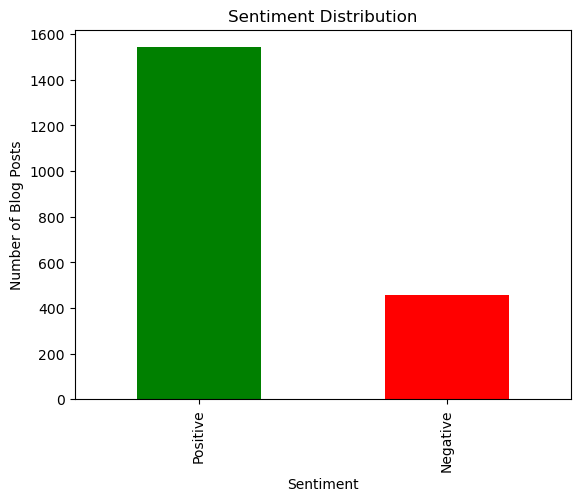

In [19]:
# Get the distribution of sentiments across all blog posts
sentiment_distribution = data['Sentiment'].value_counts()
print("Sentiment Distribution:")
print(sentiment_distribution)

# Optional: Visualize the sentiment distribution using a bar plot
import matplotlib.pyplot as plt

sentiment_distribution.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Blog Posts')
plt.show()


Sentiment Distribution Across Categories:
Sentiment                 Negative  Positive
Labels                                      
alt.atheism                     23        77
comp.graphics                   24        76
comp.os.ms-windows.misc         22        78
comp.sys.ibm.pc.hardware        20        80
comp.sys.mac.hardware           24        76
comp.windows.x                  27        73
misc.forsale                    16        84
rec.autos                       17        83
rec.motorcycles                 26        74
rec.sport.baseball              29        71
rec.sport.hockey                34        66
sci.crypt                       19        81
sci.electronics                 19        81
sci.med                         29        71
sci.space                       27        73
soc.religion.christian          13        87
talk.politics.guns              30        70
talk.politics.mideast           22        78
talk.politics.misc              22        78
talk.religion

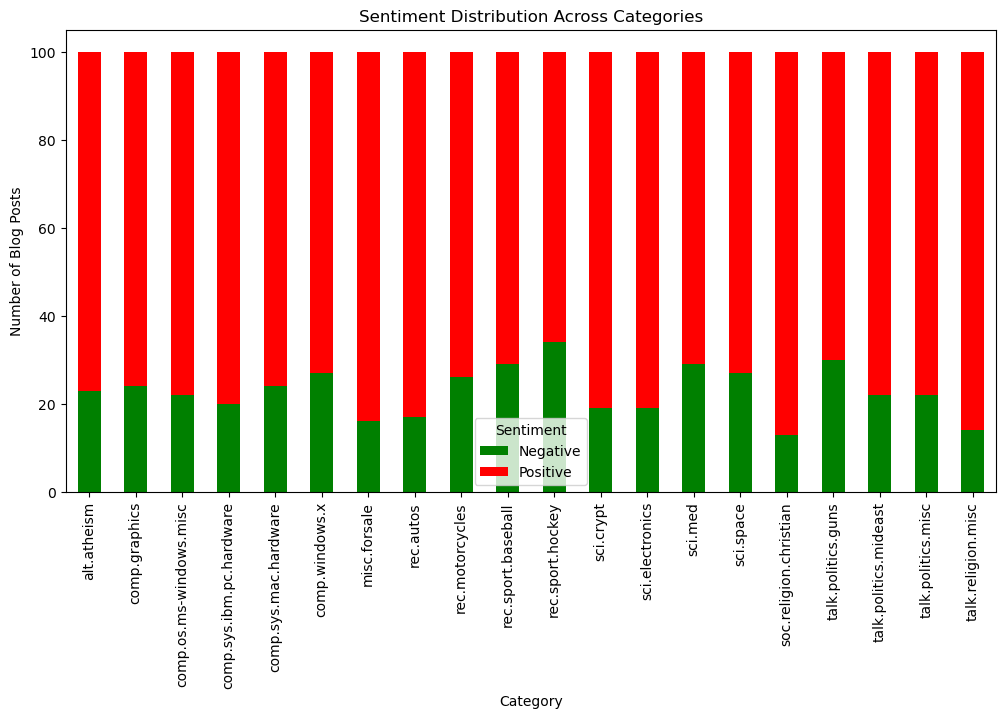

In [20]:
# Analyze sentiment distribution within each category
category_sentiment_distribution = data.groupby(['Labels', 'Sentiment']).size().unstack(fill_value=0)

# Display the distribution
print("Sentiment Distribution Across Categories:")
print(category_sentiment_distribution)

# Optional: Visualize sentiment distribution for categories
category_sentiment_distribution.plot(kind='bar', stacked=True, figsize=(12, 6), color=['green', 'red', 'blue'])
plt.title('Sentiment Distribution Across Categories')
plt.xlabel('Category')
plt.ylabel('Number of Blog Posts')
plt.legend(title='Sentiment')
plt.show()


In [24]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Assume the dataset has two columns: 'text' for blog content and 'label' for sentiment
# Modify column names as per your dataset
text_column = 'Data'  # Replace with the actual column name for blog content
label_column = 'Sentiment'  # Replace with the actual column name for sentiment

# Split data into features (X) and labels (y)
X = data[text_column]
y = data[label_column]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Convert text data to feature vectors using CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
X_train_vectors = vectorizer.fit_transform(X_train)
X_test_vectors = vectorizer.transform(X_test)

# Train a Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train_vectors, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_vectors)

# Evaluate the performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print("Model Performance:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Discuss performance and challenges
print("\nDiscussion:")
print("The Naive Bayes classifier performed reasonably well for sentiment analysis. Challenges might include handling imbalanced datasets or noisy data in blog posts. Further preprocessing or using more sophisticated models could improve performance.")


Model Performance:
Accuracy: 0.78
Precision: 0.70
Recall: 0.78
F1-Score: 0.71

Classification Report:
              precision    recall  f1-score   support

    Negative       0.32      0.06      0.10       124
    Positive       0.80      0.97      0.87       476

    accuracy                           0.78       600
   macro avg       0.56      0.51      0.49       600
weighted avg       0.70      0.78      0.71       600


Discussion:
The Naive Bayes classifier performed reasonably well for sentiment analysis. Challenges might include handling imbalanced datasets or noisy data in blog posts. Further preprocessing or using more sophisticated models could improve performance.


In [23]:
data.columns


Index(['Data', 'Labels', 'Processed_Data', 'Sentiment'], dtype='object')